In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
import os
import dotenv
import numpy as np
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from matplotlib import pyplot as plt
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager

In [2]:
dotenv.load_dotenv()
ibm_token = os.getenv("ibm_token")
ibm_CRN = os.getenv("ibm_CRN")
# print(ibm_token)
# print(ibm_CRN)

In [3]:
QiskitRuntimeService.save_account(
    token=ibm_token,
    instance=ibm_CRN,
    overwrite=True
)
service = QiskitRuntimeService()

# backend = service.least_busy(
#     operational=True, simulator=False
# )
backend = backend = service.backend("ibm_kingston")

In [4]:
print(f"Targeting QPU: {backend.name}")
print(f"Qubit Count: {backend.num_qubits}")

Targeting QPU: ibm_kingston
Qubit Count: 156


In [5]:
qb = 7
nums = [68, 103, 119, 45]
shots = 1000

zeta = np.arcsin(np.sqrt(len(nums) / (2 ** qb)))
print(f'zeta: {zeta / np.pi * 180:.2f}')

iters = round(np.pi / (4 * zeta) - 0.5)
print(f'\nOptimal iterations: {iters}')
optimal_zeta = zeta * (2 * iters + 1)
print(f'Optimal zeta: {optimal_zeta / np.pi * 180:.2f}')

probs_true = np.abs(np.sin(optimal_zeta)) ** 2
probs_false = np.abs(np.cos(optimal_zeta)) ** 2

zeta: 10.18

Optimal iterations: 4
Optimal zeta: 91.64


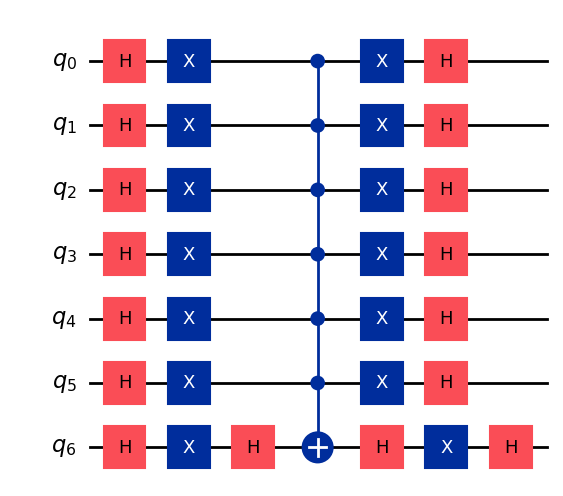

In [6]:
diffusor_qc = QuantumCircuit(qb)
diffusor_qc.name = "Diffusor"

diffusor_qc.h(range(qb))    
diffusor_qc.x(range(qb))
diffusor_qc.h(qb - 1)
diffusor_qc.mcx(list(range(qb - 1)), qb - 1)
diffusor_qc.h(qb - 1)
diffusor_qc.x(range(qb))
diffusor_qc.h(range(qb))
diffusor_qc.draw("mpl")


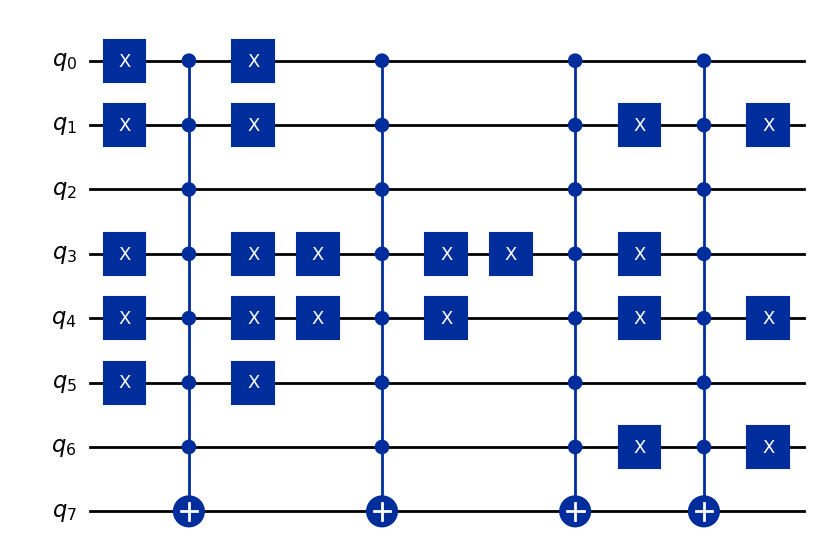

In [7]:
oracle_qc = QuantumCircuit(qb+1)
oracle_qc.name = "Oracle"

for num in nums:
    for i in range(qb):
        if int(num / (2 ** i)) % 2 == 0:
            oracle_qc.x(i)
    oracle_qc.mcx(list(range(qb)), qb)
    for i in range(qb):
        if int(num / (2 ** i)) % 2 == 0:
            oracle_qc.x(i)
oracle_qc.draw("mpl")

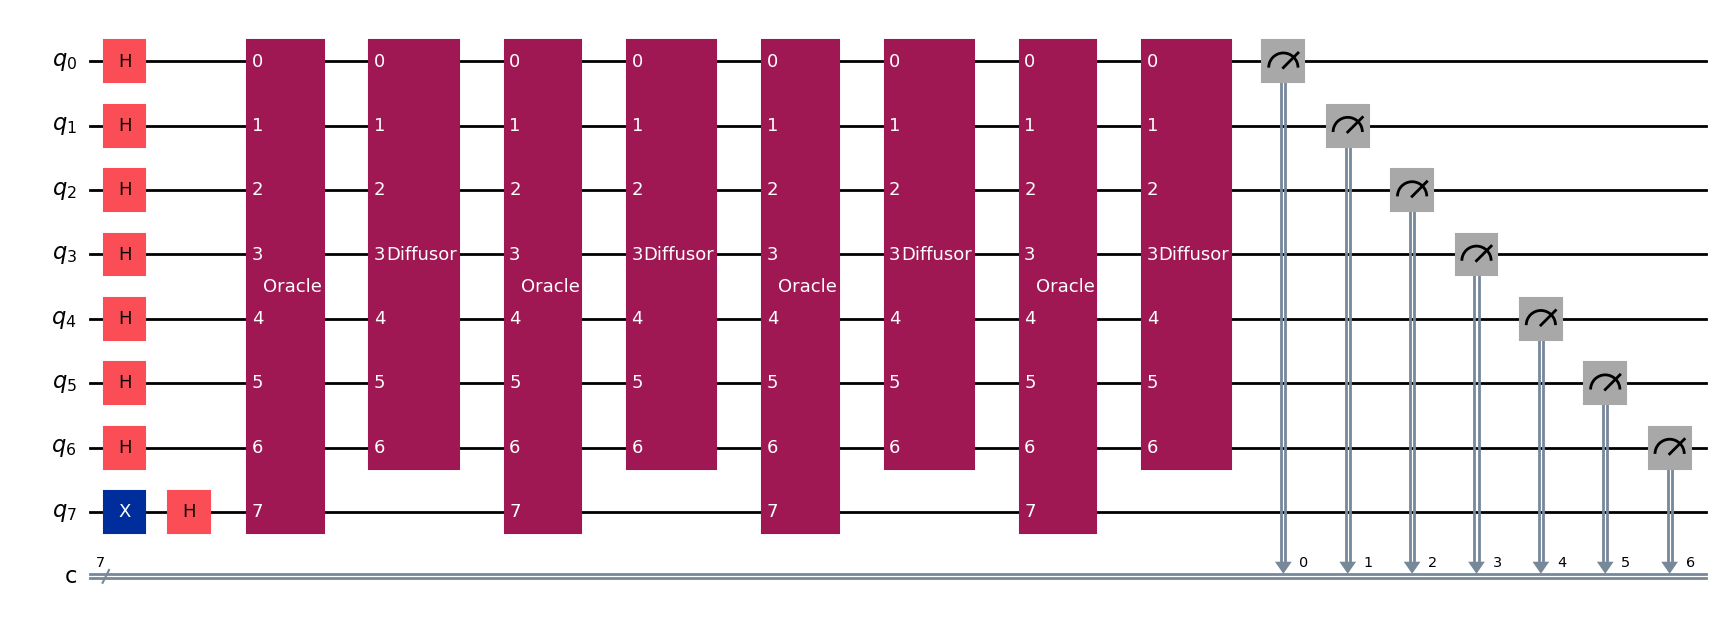

In [8]:
main_qc = QuantumCircuit(qb+1, qb)

main_qc.h(range(qb))
main_qc.x(qb)
main_qc.h(qb)
for i in range(iters):
    main_qc.append(oracle_qc, range(qb+1))
    main_qc.append(diffusor_qc, range(qb))
main_qc.measure(range(qb), range(qb))
main_qc.draw("mpl")

In [24]:
assert False

AssertionError: 

# Simulation

In [33]:
sampler = StatevectorSampler()
result = sampler.run([main_qc], shots=shots).result()

In [34]:
results = result[0].data.c.get_counts()

result_final = np.zeros(2**qb)
probs = np.zeros_like(result_final)
pt = 0
for i in results:
    result_final[int(i, 2)] = results[i]
    probs[int(i, 2)] = results[i] / shots
    if int(i, 2) in nums:
        pt += probs[int(i, 2)]
# print(probs)
print(f'Probability of measuring True: {pt:.5f}')
print(f'Probability of Theoretical True: {probs_true:.5f}')

print(f'\nProbability of measuring False: {1-pt:.5f}')
print(f'Probability of Theoretical False: {probs_false:.5f}')

Probability of measuring True: 0.99921
Probability of Theoretical True: 0.99918

Probability of measuring False: 0.00079
Probability of Theoretical False: 0.00082


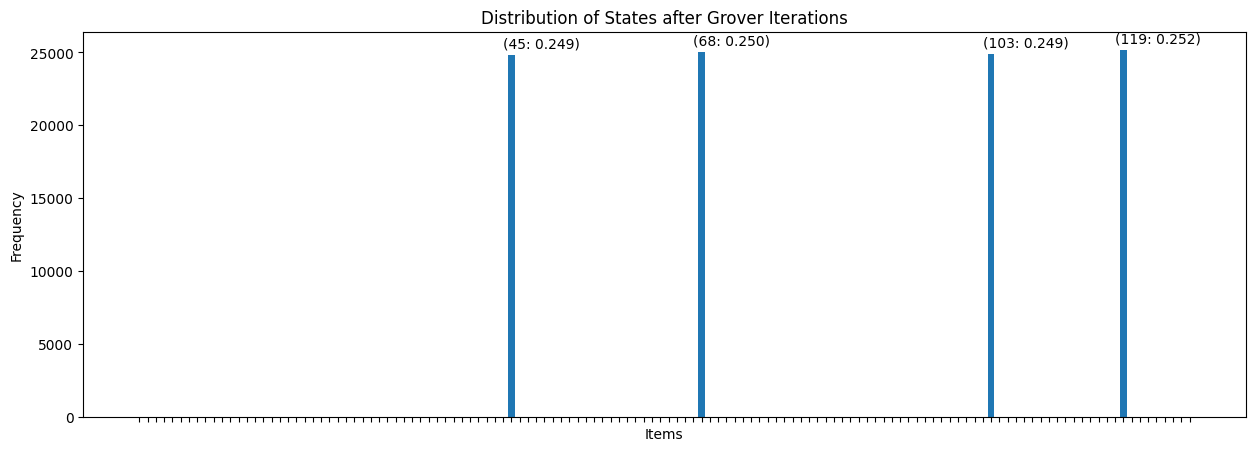

In [35]:
plt.figure(figsize=(15, 5))
x = np.arange(2**qb)
plt.bar(range(2**qb), result_final)

plt.xlabel('Items')
plt.ylabel('Frequency')
plt.title('Distribution of States after Grover Iterations')

# plt.xticks(x, [f"{i:0{qb}b}" for i in x])
# plt.xticks(x, [f"{i}" for i in x])
plt.xticks(x, [f"" for i in x])
plt.gca().set_xticklabels([])
plt.xticks(visible=False)


xlocs, xlabs = plt.xticks()
for i, s in enumerate(probs):
    if s > 0.1:
        plt.text(xlocs[i]-1, result_final[i] + shots/200, f"({i}: {s:.3f})")
plt.show()

In [ ]:
assert False

# Physical Hardware

In [55]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(main_qc)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('sx', 15695), ('rz', 11727), ('cz', 7869), ('x', 25), ('measure', 7)])


In [56]:
sampler = Sampler(mode=backend)
job = sampler.run([(isa_circuit)], shots=shots)
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d9031j9ropqc738d8nv0
>>> Job Status: QUEUED


In [9]:
job = service.job('d9031j9ropqc738d8nv0')
result = job.result()

In [10]:
results = result[0].data.c.get_counts()

result_final = np.zeros(2**qb)
probs = np.zeros_like(result_final)
pt = 0
for i in results:
    result_final[int(i, 2)] = results[i]
    probs[int(i, 2)] = results[i] / shots
    if int(i, 2) in nums:
        pt += probs[int(i, 2)]
# print(probs)
print(f'Probability of measuring True: {pt:.5f}')
print(f'Probability of Theoretical True: {probs_true:.5f}')

print(f'\nProbability of measuring False: {1-pt:.5f}')
print(f'Probability of Theoretical False: {probs_false:.5f}')

Probability of measuring True: 0.02800
Probability of Theoretical True: 0.99918

Probability of measuring False: 0.97200
Probability of Theoretical False: 0.00082


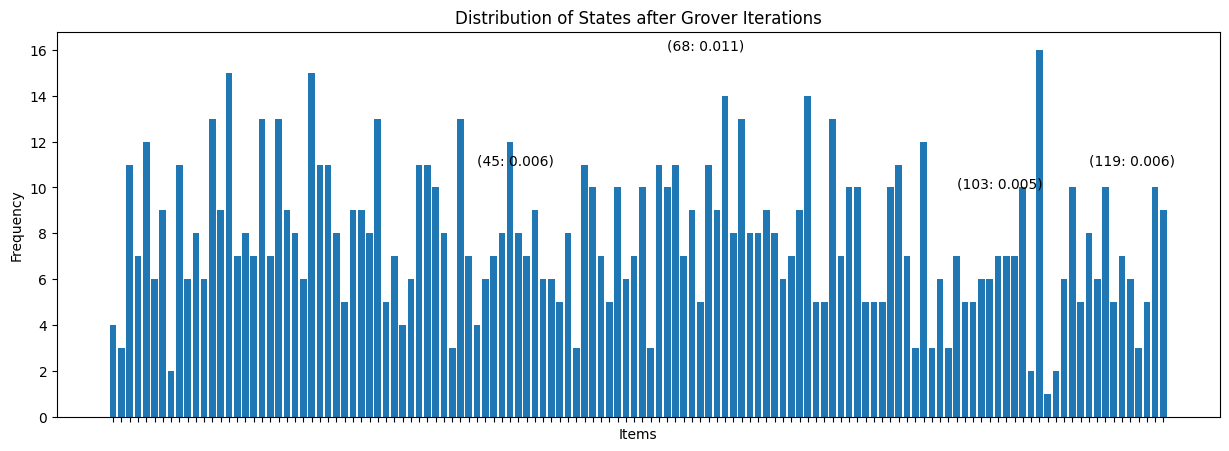

In [11]:
plt.figure(figsize=(15, 5))
x = np.arange(2**qb)
plt.bar(range(2**qb), result_final)

plt.xlabel('Items')
plt.ylabel('Frequency')
plt.title('Distribution of States after Grover Iterations')

# plt.xticks(x, [f"{i:0{qb}b}" for i in x])
# plt.xticks(x, [f"{i}" for i in x])
plt.xticks(x, [f"" for i in x])
plt.gca().set_xticklabels([])
plt.xticks(visible=False)


xlocs, xlabs = plt.xticks()
for i, s in enumerate(probs):
    # if s > 0.1:
    if i in nums:
        plt.text(xlocs[i]-1, result_final[i] + shots/200, f"({i}: {s:.3f})")
plt.show()